In [1]:
import pandas as pd

df=pd.read_csv("C:/Users/Asus/OneDrive/Masaüstü/BİTİRME/csv dosyalari/hotels_cleaned.csv", sep=';', encoding='utf-8-sig')
df.head()

,hotel_name,district,hotel_type,url,data_scraped_time,latitude,longitude,original_price,discount_price_per_night,discount_rate,...,parking,pool,spa,rating,num_reviews,weighted_rating,review_text,review_date,review_rating,review_language
0,Lara Barut Collection,Muratpaşa,Resort,https://tr.hotels.com/ho233845/lara-barut-coll...,2025-10-11,36.858194,30.856247,73910,47579,0.356,...,True,True,True,9.6,1004,9.494821,"""Great stay""",2025-08-29,10.0,EN
1,Lara Barut Collection,Muratpaşa,Resort,https://tr.hotels.com/ho233845/lara-barut-coll...,2025-10-11,36.858194,30.856247,73910,47579,0.356,...,True,True,True,9.6,1004,9.494821,"""Das Hotel ist einfach klasse – es fehlt einem...",2025-08-28,10.0,DE
2,Lara Barut Collection,Muratpaşa,Resort,https://tr.hotels.com/ho233845/lara-barut-coll...,2025-10-11,36.858194,30.856247,73910,47579,0.356,...,True,True,True,9.6,1004,9.494821,"""Beautiful resort, clean and spacious. Food wa...",2025-08-22,10.0,EN
3,Lara Barut Collection,Muratpaşa,Resort,https://tr.hotels.com/ho233845/lara-barut-coll...,2025-10-11,36.858194,30.856247,73910,47579,0.356,...,True,True,True,9.6,1004,9.494821,"""Lovely family hotel""",2025-08-17,10.0,EN
4,Lara Barut Collection,Muratpaşa,Resort,https://tr.hotels.com/ho233845/lara-barut-coll...,2025-10-11,36.858194,30.856247,73910,47579,0.356,...,True,True,True,9.6,1004,9.494821,"""The Lara Barut resort is pure perfection — a ...",2025-08-17,10.0,EN


## Dil Filtreleme

Öncelikle İngilizce(EN) yorumları ayıklayacağız. 

Preprocessing ile, bilgisayara anlam yüklemeden önce kelimeleri tarayıp temizleyeceğiz.

Veri setindeki yorumlar gürültülüdür. (noktalama işaretleri, büyük/küçük harf karmaşası, sayılar). Bu gürültüleri temizlemeden modele verirsek, model "Muhteşem!" ile "muhteşem." kelimelerini iki farklı şey sanar.

Vectorization(kelimelerin vektörel uzaydaki konumu) öğrenilecek: 
- Tokenization: Cümleyi atomlarına parçalamak
- Stopwords: "Gürültü" olan kelimeleri ayıklamak
- Lemmatization: Kelimenin maskesini düşürüp kökünü bulmak. Örn: imrpoved-> improve, worse-> bad

- NLP Pipeline: Veriyi hazırlama. Önce sadece İngilizce(EN) yorumları ayıklayarak başlayalım ki kullanacağımız kütüphaneler şaşırmasın.

In [2]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# gerekli kaynakları indirelim
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
# Sadece İngilizce yorumları filtreleyelim.
df_en= df[df['review_language'] == 'EN'].copy()
print(f"Toplam İngilizce yorum sayısı: {len(df_en)}")

Toplam İngilizce yorum sayısı: 2139


Iterasyon: .apply() komutu, review_text sütunundaki her bir satırı tek tek gezer.

Parametre Aktarımı: Sütundaki ilk satırı alır ve onu clean_text fonksiyonuna gönderir.

İsimlendirme: Fonksiyonun içine giren o satır, fonksiyonun içinde artık text ismini alır.

İşlem: text = str(text).lower() dediğimizde, o an içeride olan satırı küçük harfe çeviririz.

Geri Dönüş (Return): İşlem bitince temizlenmiş hali dışarı çıkar (return) ve yeni oluşturduğumuz cleaned_text sütununa yazılır.

In [4]:
"""
lemmatizasyon: bir kelimenin doğru kök biçimini WordNet gibi bir sözcük veri tabanında inceleyerek belirler.
Daha doğru sonuçlar almak için sözcük türü (POS) belirtilebilir.
Lemmatize etmek (lemmatization),kelimeleri sadece son eklerinden ayıran stemming (kök bulma)'den farklı olarak,
bağlamı ve kelime türünü (isim, fiil) dikkate alır. 
""" 

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()
lemma = lemmatizer.lemmatize("learning",pos=wordnet.VERB)
print(lemma)


learn


###
Otel yorumlarında genellikle sıfatlar (clean, beautiful, bad) ve isimler (room, staff, food) duygu analizini belirler. Lemmatizer varsayılan olarak isimleri (örneğin "amenities" -> "amenity") zaten iyi yakaladığı için başlangıç seviyesinde POS eklemeden ilerlemek yaygın bir tercihtir. WordCloud çalıştığında eğer en büyük kelimeler düzgün köklerine inmişse (Örn: "services" yerine "service"), şu anki hali yeterlidir.

In [5]:
def deep_clean_text(text):
    # 1. Küçük harf (case sensitivity'i önlemek için)
    text = str(text).lower()
    
    # 2. Noktalama ve sayı temizliği (Regex)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    
    # 3. Tokenization
    tokens = word_tokenize(text)
    
    # 4. Stopwords Removal
    stop_words = set(stopwords.words('english'))
    # w, tokens içinde dolaşacak, eğer stopword değilse tokens listesine yazılacak
    tokens = [w for w in tokens if w not in stop_words]
    
    # 5. Lemmatization
    # tokens lemmatize edilecek.
    
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    
    # 6. Tekrar birleştir
    return " ".join([w for w in tokens if len(w) >1])

# Şimdi temizliği uygulayalım
df_en['cleaned_text'] = df_en['review_text'].apply(deep_clean_text)

# Tekrar kontrol edelim
comparison = df_en[['review_text', 'cleaned_text']].head(5)

for index, row in comparison.iterrows():
    print(f"--- Review {index+1} ---")
    print(f"Orijinal: {row['review_text']}")
    print(f"Temiz: {row['cleaned_text']}")

--- Review 1 ---
Orijinal: "Great stay"
Temiz: great stay
--- Review 3 ---
Orijinal: "Beautiful resort, clean and spacious. Food was excellent, services were outstanding, right on the beach. Shows were beautiful, polls were clean and never crowded. Very family friendly, waterpark was excellent for kids. We plan to go back and to recommend this resort to anybody, especially families."
Temiz: beautiful resort clean spacious food excellent service outstanding right beach show beautiful poll clean never crowded family friendly waterpark excellent kid plan go back recommend resort anybody especially family
--- Review 4 ---
Orijinal: "Lovely family hotel"
Temiz: lovely family hotel
--- Review 5 ---
Orijinal: "The Lara Barut resort is pure perfection — a playground of endless amenities and culinary delights from every corner of the globe to tempt every palate. The staff are highly motivated, warm and welcoming. Effortlessly professional, they anticipate your needs before you even think of the

### 
Şu an 4000 yorumda .iterrows() kullanmak pratiktir 
ve öğrenmek için en iyisidir. Ancak ileride milyonlarca satırla çalışırken
.iterrows() yavaş kalabilir. O zamanlarda .apply() veya Vectorization teknikleri kullanılır. 
Ama şimdilik, veriyi "görmek" ve "kontrol etmek" için  profesyonel yol budur.

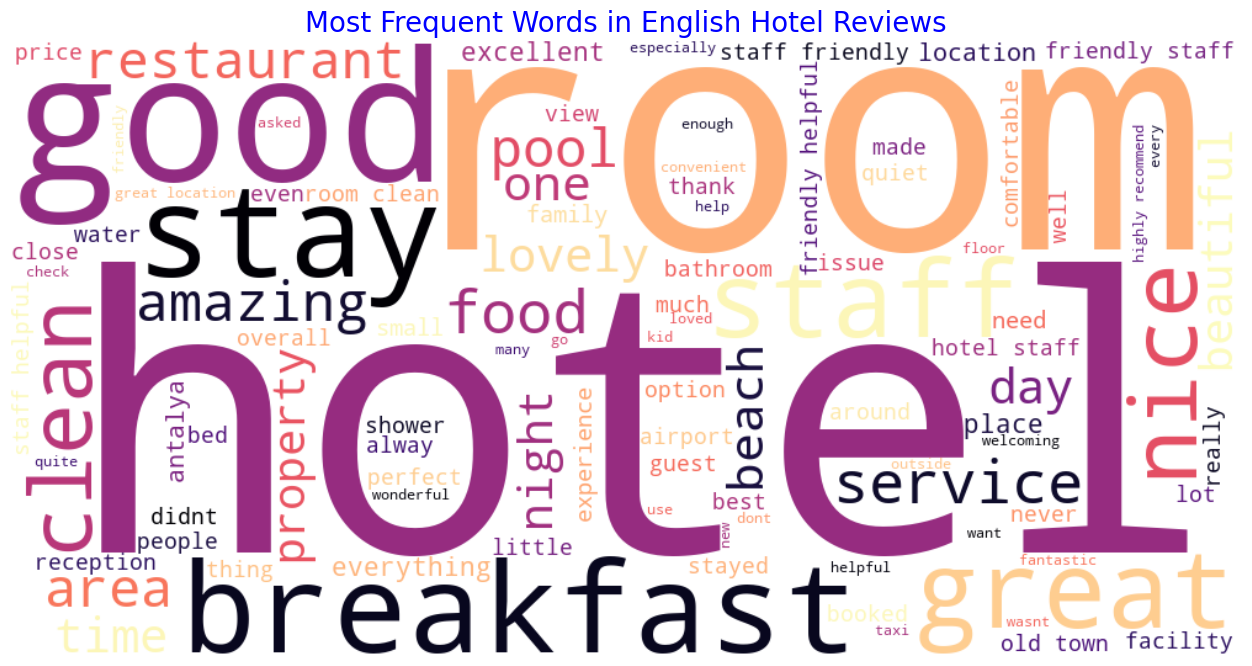

In [6]:
# Wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Tüm temizlenmiş yorumları tek bir metin haline getirme
all_reviews = " ".join(df_en['cleaned_text'])

# WordCloud objesi
wordcloud = WordCloud(width=1000, height=500, 
                      background_color='white',
                      colormap='magma',
                      max_words=100).generate(all_reviews)
                      # en çok tekrar eden 100 kelime
                      
# Görselleştirme
plt.figure(figsize=(20,8), facecolor=None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')     # eksenler kapalı
plt.title("Most Frequent Words in English Hotel Reviews",fontsize=20, color='Blue')
plt.show()

## wordcloud analizi
Dominant kelimeler: hotel, room 

Duygu sinyalleri: good, clean, stay. Sentiment analysis için kullanılacak. Genel kullanıcı deneyimi (sentiment) pozitif tarafa meyilli.

Breakfast'ın pool ve beach'ten büyük çıkması şaşırtıcı. Kahvaltı, müşteri memnuniyeti üzerinde kritik bir belirleyici.

## 
Kelimeleri gördük şimdi her yoruma bir mutluluk puanı vereceğiz. Bunun için VADER kütüphanesini kullancağız. 

VADER, sosyal medya ve yorumlar için geliştirilmiş kural tabanlı duygu analizcidir. Cümledeki kelimelerin şiddetini(örneğin excellent > good ) ve bağlamı (olumsuzluk eklerini) anlar.


In [7]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# VADER için gerekli sözlüğü indirelim.
nltk.download('vader_lexicon')

# analizciyi başlatalım
sia = SentimentIntensityAnalyzer()

# örnek bir cümlenin skoru nasıl hesaplanıyor?
test_sentence = "Lovely family hotel"
print(f"Skor: {sia.polarity_scores(test_sentence)}")

Skor: {'neg': 0.0, 'neu': 0.345, 'pos': 0.655, 'compound': 0.5859}


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [8]:
# tüm temizlenmiş İngilizce yorumlara uygula.
# compound skoru -1 ile +1 arasında değer alır.

df_en['sentiment_score'] = \
df_en['cleaned_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

# skorlara göre kategorize işlemi

def get_sentiment_label(score):
    if score >= 0.05:
        return "Positive"
    elif score <=-0.05:
        return "Negative"
    else:
        return "Neutral"

df_en['sentiment_label'] = df_en['sentiment_score'].apply(get_sentiment_label)

print('Sentiment distribution')
print(df_en['sentiment_label'].value_counts())

Sentiment distribution
sentiment_label
Positive    1819
Negative     220
Neutral      100
Name: count, dtype: int64


#
word cloud'a göre positive sayısı daha çok çıkmalıydı. SIA ile bu kanıtlandı. 

Peki bu 220 negatif yorum neden? Bu yorumlarda hangi kelimeler geçiyor?
Negatif yorumların wordcloud'una bakalım.
Bu aşama, işletmeler için "Şunu düzeltmelisiniz" demeyi sağlayan içgörü aşamasıdır.

Text(0.5, 1.0, 'Common Complaints in Negative Reviews')

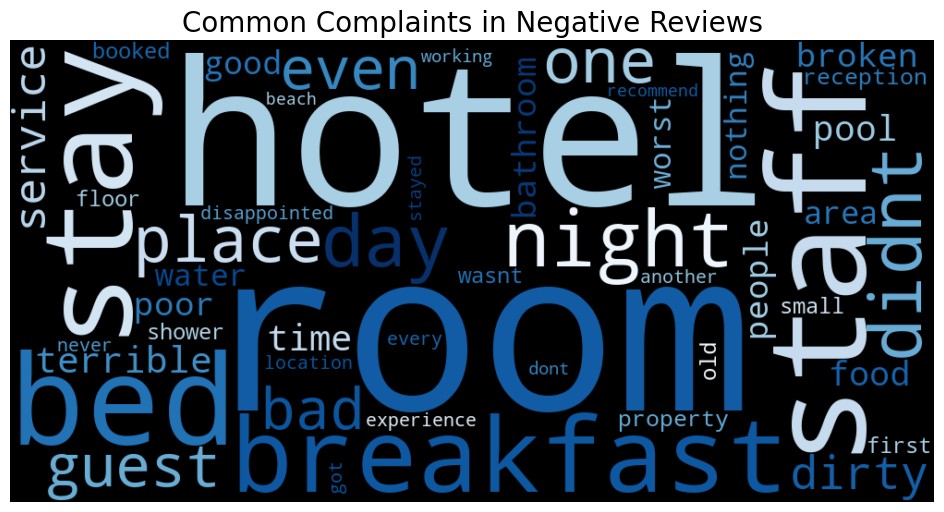

In [9]:
from wordcloud import WordCloud 
import matplotlib.pyplot as plt 

neg_reviews = df_en[df_en['sentiment_label'] == 'Negative']['cleaned_text']

# bu negatif yorumlardaki kelimeleri tek bir metne dönüştür.
neg_text = " ".join(neg_reviews) 

# wordcloud
neg_wordcloud = WordCloud(width=1000, height=500,
                         background_color='black',
                         colormap='Blues',
                         max_words=50).generate(neg_text)

plt.figure(figsize=(12,6))
plt.imshow(neg_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Common Complaints in Negative Reviews", fontsize=20, color="Black")

# 
Room & Small: Odaların boyutları beklentinin altında kalmış.

Food & Service: Mutfak ve hizmet kalitesinde aksamalar var.

Disappointing: Bu çok güçlü bir duygu kelimesidir. Beklenti (Expectation) ile gerçek (Reality) arasındaki farkın açıldığını gösterir.

## Consistency analysis

Verideki çelişkilere bakılacak.

VADER ham veriyi sever. Bu yüzden temizlenmiş metni değil direkt review_text'i kullanacağız.

- Noktalama İşaretleri: VADER için "!!!" işareti duygunun şiddetini artırır. "Great!!!" ile "great" aynı puanı almaz.

- Büyük Harf (Capitalization): "This hotel is BAD" dediğinde, VADER o büyük harfli "BAD" kelimesinin çok daha negatif olduğunu anlar.

- Bağlaçlar (Stopwords): "but", "however" gibi kelimeler duygunun yön değiştirdiğini belirtir.

cleaned_text kullanırsan: VADER sadece kök kelimelere bakar. "no", "not", "but" gibi kelimeler gittiği için "not bad" (fena değil) ifadesini sadece "bad" (kötü) olarak algılayıp yanlış sonuç verebilir.

review_text (Ham Metin) kullanırsan: VADER; ünlemleri, büyük harf vurgularını ve "not", "never" gibi olumsuzluk eklerini kullanarak çok daha hassas bir ölçüm yapar.

In [10]:
# Sitedeki puanlama sistemi 2,4,6,8,10 şeklinde.
# 8-10 memnuniyet bölgesi. 
# Rating'i 8 ve üzerinde olan ama VADER'ın negative dediği kafa karıştırıcı yorumlar

false_negatives = df_en[(df_en['review_rating'] >= 8.0) & (df_en['sentiment_label'] == 'Negative')]

# Puanı düşük ama modelin "iyi" dediği yorumlar.
false_positives = df_en[(df_en['review_rating'] <= 4.0) & (df_en['sentiment_label'] == 'Positive')]

print(f"Tespit edilen false negative'lerin sayisi: {len(false_negatives)}")
print(f"Tespit edilen false positive'lerin sayisi: {len(false_positives)}")

Tespit edilen false negative'lerin sayisi: 32
Tespit edilen false positive'lerin sayisi: 89


## 
false negative'ler için: Örneğin kullanıcı 10 puan vermiş ama yorumda sadece küçük bir teknik aksaklıktan (örn: "elevator was slow") bahsetmiş. VADER bu tek kelimeye takılıp negatif demiş.

false positive'ler için: 
- Polite Complaints (Nazik Şikayetler): "The staff was very friendly and helpful, but unfortunately the room was dirty." VADER buradaki "friendly" ve "helpful" kelimelerine yüksek puan verip "dirty"nin ağırlığını yenmiş olabilir.
- Sarcasm (İroni): "Great, another hotel with no hot water. Just perfect!" VADER buradaki "Great" ve "Perfect" kelimelerini görünce bayram ediyor ama aslında durum felaket.

In [11]:
# false negative için rastgele 3'ine bakalım.
sample_fn = false_negatives[['review_rating', 'review_text', 'sentiment_score']].head(3)

for index, row in sample_fn.iterrows():
    print("---Sample---")
    print(f"Rating: {row['review_rating']}")
    print(f"VADER Score: {row['sentiment_score']}")
    print(f"Review Text: {row['review_text']}")
    print("-" * 30)

---Sample---
Rating: 8.0
VADER Score: -0.3687
Review Text: "Guest service were accommodating on our arrival, as we arrived 4am into the hotel. However, dining options were limited, the all day buffet, wasn’t the best in terms of variations from each day. Not eating beef, the meat options were limited. The pool areas and kids club (inc night time entertainment) we’re brilliant and the kids enjoyed themselves. Overall, it was ok, not the worst, but not the best."
------------------------------
---Sample---
Rating: 8.0
VADER Score: -0.6348
Review Text: "The receptionist said they know nothing about Expedia VIP benefits and ask to call Expedia."
------------------------------
---Sample---
Rating: 10.0
VADER Score: -0.1531
Review Text: "Family Trip.Hotel is big and away from the city family oriented but not much of kids activities Food not bad and reasonable however staff are very rude and lack the welcoming aspect very hard to communicates with or even do the extra mile for the comfort of 

## 
"not the worst, but not the best." gibi ifadeler modeli kitliyor. Cümlede olumsuzluk ekleri ve sözcükleri daha fazla olduğu için VADER bunlara takılıyor.

In [12]:
# false positive'ler için rastgele 3 tanesine bakalım.
sample_fp = false_positives[['review_rating', 'review_text', 'sentiment_score']].head(3)

for index,row in sample_fp.iterrows():
    print("---Sample---")
    print(f"Rating:{row['review_rating']}")
    print(f"VADER Score: {row['sentiment_score']}")
    print(f"Review Text: {row['review_text']}")
    print('-' * 30)


---Sample---
Rating:4.0
VADER Score: 0.9372
Review Text: "Skip this place. I really wanted to like this resort, but so much was amiss. Reception on arrival was barely welcoming and told us little about the hotel. The room was lovely (we had a penthouse). It was impossible to book a restaurant on day 1. The next couple of days were booked up; they eventually found us one “due to a cancellation.” Yet half the dining room was empty, so something didn’t add up. We had a truly disturbing experience in the spa—one I’ve never encountered in my life. It’s not suitable to print the details. The hotel tried to make amends and the team member was asked to leave, but it left a bad taste over the rest of the holiday. I later discovered they only refunded £129 of the £258 they’d agreed to—disingenuous, given what happened. The restaurants (when you could get into them) were excellent. Yet other details were hit and miss—an announcement that children had to wear water diapers played on repeat all aft

## 
Sorun: "Would not recommend" (Tavsiye etmem).
Teknik Sebep: VADER’ın en büyük zaafı! "Recommend" kelimesi sözlükte pozitiftir. Başındaki "not" (olumsuzluk eki) bazen skoru tam negatife çekmeye yetmez veya "would" ile birleşince VADER’ın kafası karışır.

VADER, nazikçe yapılan veya uzun cümleler arasına gizlenen sert eleştirileri yakalamakta zorlanıyor.

## Sentiment Accuracy Score

NLP ve EDA aşamaları birleştirilecek.

Model ne kadar başarılı? FP-TP toplam 121 hata.

In [13]:
total_reviews = len(df_en)
total_errors = len(false_negatives) + len(false_positives)
accuracy = (total_reviews - total_errors) / total_reviews

print(f"Toplam İngilizce Yorum Sayisi: {total_reviews}")
print(f"Toplam Hata Sayisi: {total_errors}")
print(f"Doğruluk Oranı(Accuracy Score) :%{accuracy * 100:.2f}")

Toplam İngilizce Yorum Sayisi: 2139
Toplam Hata Sayisi: 121
Doğruluk Oranı(Accuracy Score) :%94.34


##
Model, müşteri duyarlılığını yüksek bir güvenilirlikle temsil etmektedir.

##
Sadece rating'e göre değil VADER'ın hesapladığı sentiment_score'lara göre en yüksek ortalamaya sahip otelleri listeleyelim. Böylece gerçek müşteri memnuniyeti elde edilecektir.

In [14]:
hotel_sentiment = df_en.groupby('hotel_name')['sentiment_score'].mean().sort_values(ascending=False)

# En iyi ve en kötü 5 oteli listeleyelim.
top_5_happy = hotel_sentiment.head(5)
bottom_5_happy = hotel_sentiment.tail(5)

print(top_5_happy)
print(bottom_5_happy)

hotel_name
Echinus Blue Hotel    0.9908
Af-Ra Hotel           0.9882
Casativo Hotels       0.9857
Nasa Flora Hotel      0.9836
Hotel Royal Hill      0.9690
Name: sentiment_score, dtype: float64
hotel_name
Nun Hotel Lara        -0.259375
Ahsen Hotel Antalya   -0.306200
Kartal Hotel          -0.401900
Kaleiçi Butik Otel    -0.526700
Deluxe Ersoy Hotel    -0.851900
Name: sentiment_score, dtype: float64


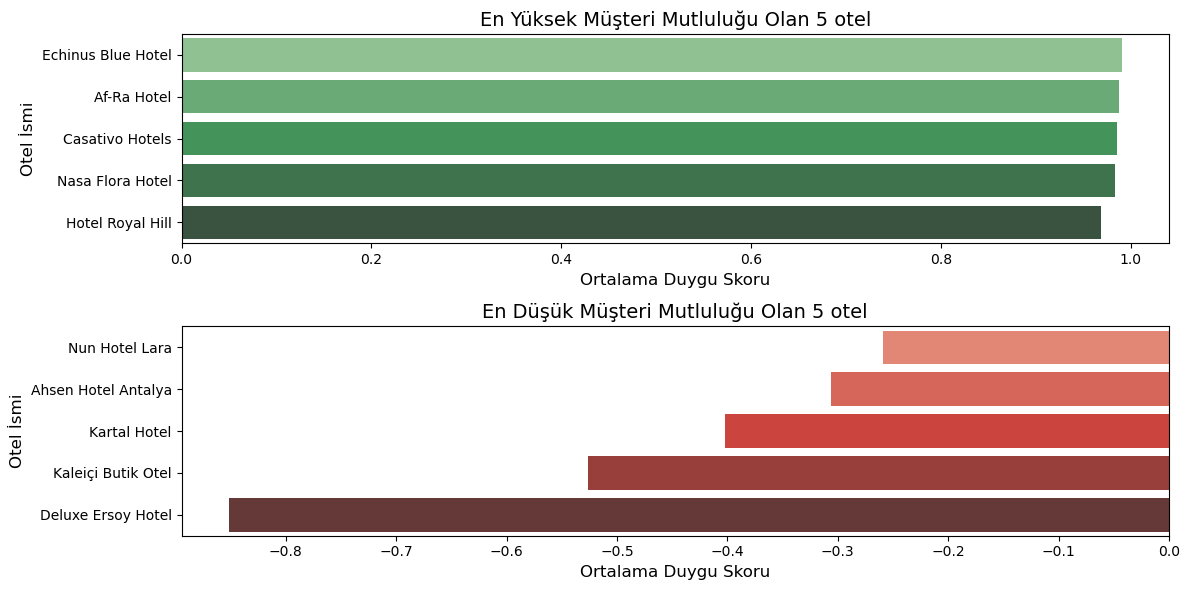

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# 1. En mutlu 5 otel
plt.subplot(2,1,1)
sns.barplot(x=top_5_happy.values, y=top_5_happy.index, palette='Greens_d')
plt.title("En Yüksek Müşteri Mutluluğu Olan 5 otel", fontsize=14)
plt.xlabel("Ortalama Duygu Skoru", fontsize=12)
plt.ylabel("Otel İsmi", fontsize=12)

# 2. En mutsuz 5 otel
plt.subplot(2,1,2)
sns.barplot(x=bottom_5_happy.values, y=bottom_5_happy.index, palette='Reds_d')
plt.title("En Düşük Müşteri Mutluluğu Olan 5 otel", fontsize=14)
plt.xlabel("Ortalama Duygu Skoru", fontsize=12)
plt.ylabel("Otel İsmi", fontsize=12)

plt.tight_layout()
plt.show()

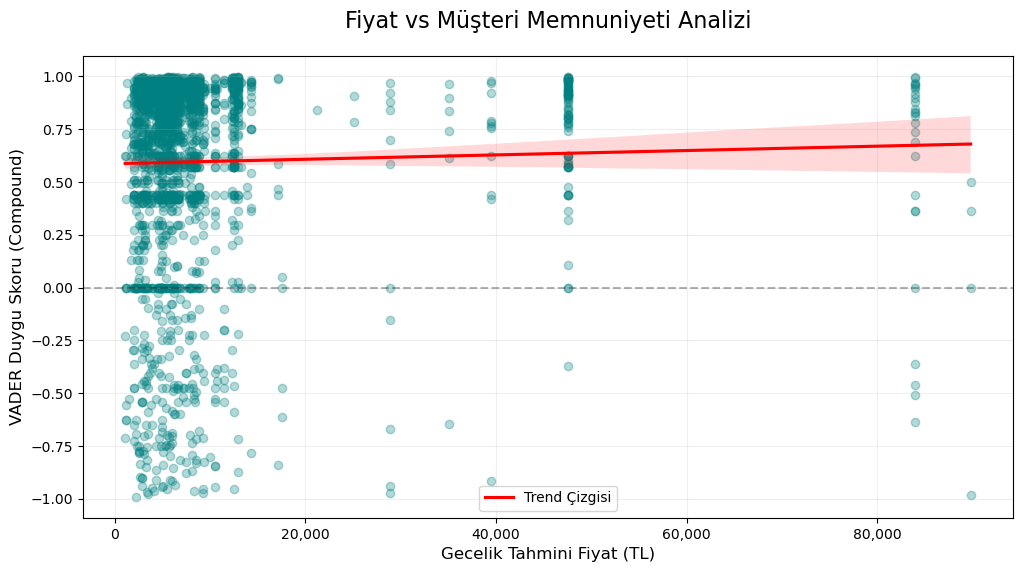

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

plt.figure(figsize=(12,6))

# scatter plot + regression line
# x: gecelik fiyat, y: mutluluk skoru
sns.regplot(x='discount_price_per_night', y='sentiment_score', data=df_en,
           scatter_kws={'alpha':0.3, 'color':'teal'},
           line_kws={'color':'red','label':'Trend Çizgisi'})

plt.title("Fiyat vs Müşteri Memnuniyeti Analizi", fontsize=16, pad=20)
plt.xlabel('Gecelik Tahmini Fiyat (TL)', fontsize=12)
plt.ylabel('VADER Duygu Skoru (Compound)', fontsize=12)

# Fiyat eksenini 500, 1000 gibi temiz göstermek için
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.axhline(0, color='black', linestyle='--', alpha=0.3)   # nötr çizgisi
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

Trend Çizgisinin Yönü (Kırmızı Çizgi): Çizgi neredeyse tamamen yatay ilerliyor. Bu, Antalya otel pazarında "fiyat" ile "müşteri mutluluğu" (VADER skoru) arasında matematiksel olarak anlamlı bir korelasyon (bağ) olmadığını gösterir.

Verilerin Dağılımı (Mavi Noktalar): Noktalar grafiğin her tarafına saçılmış.

Sol Taraf (Ekonomik Oteller): Gecelik fiyatın görece düşük olduğu bölgede, VADER skoru 1.0 (tam mutluluk) olan onlarca otel var.

Sağ Taraf (Lüks Oteller): İnsanlar yine 1.0 ile 0.0 (nötr) arasında dağılmış. 

'Ne kadar çok para, o kadar çok mutluluk' diye bir kural geçerli değil. Müşteriler ekonomik otellerde de harika deneyimler yaşayabiliyor. Lüks otel işletmecileri için bu bir risk sinyalidir; çünkü çok para alan otel, beklentiyi de çok yükseltiyor. Ve grafikte gördüğümüz gibi lüks oteller her zaman o yüksek beklentiyi karşılayamıyor.


<Figure size 1200x600 with 0 Axes>

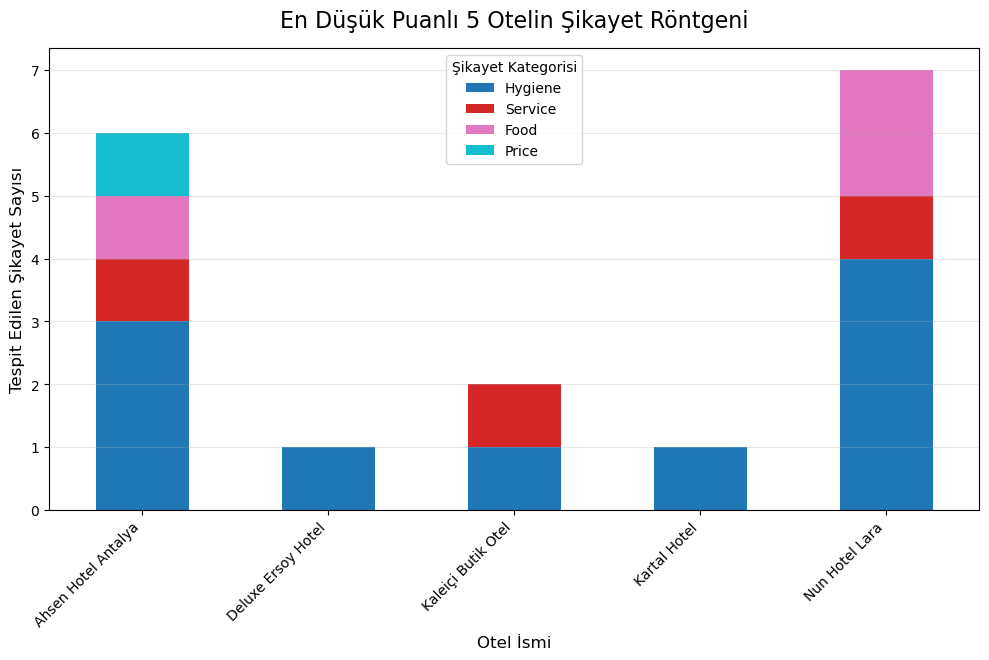

In [17]:
# Her bir yorumun içinde spesifik "şikayet kelimeleri" arayıp
# bunları departmanlara (Hijyen, Servis, Yemek, Fiyat) böleceğiz.

# 1. Şikayet kategorilerini ve anahtar kelimeleri tanımlayalım
complaint_keywords = {
    'Hygiene': 'dirty|room|clean|smell|bathroom|bed', 
    'Service': 'rude|staff|reception|service|waiter', 
    'Food': 'food|buffet|breakfast|meat|dining',      
    'Price': 'expensive|money|price|value|cost'       
}

# 2. Sadece en düşük sentiment skoruna sahip 5 oteli filtreleyelim.
# (Daha önce hotel_sentiment.tail(5).index ile belirlemiştik)
bad_hotels = df_en[df_en['hotel_name'].isin(bottom_5_happy.index)].copy()

# 3. Her bir kategoride geçen kelime sayılarını sütun olarak ekleyelim
for dept, keywords in complaint_keywords.items():
    bad_hotels[dept] = bad_hotels['cleaned_text'].str.contains(keywords, case=False).astype(int)

# 4. Otel bazında gruplayıp şikayetleri toplayalım
analysis = bad_hotels.groupby('hotel_name')[list(complaint_keywords.keys())].sum()

# 5. Görselleştirme
plt.figure(figsize=(12, 6))
analysis.plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab10')

plt.title('En Düşük Puanlı 5 Otelin Şikayet Röntgeni', fontsize=16, pad=15)
plt.ylabel('Tespit Edilen Şikayet Sayısı', fontsize=12)
plt.xlabel('Otel İsmi', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Şikayet Kategorisi')
plt.grid(axis='y', alpha=0.3)
plt.show()

## 
En düşük puanlı 5 oteldeki mutsuzluğun en büyük ve ortak sebebi, tüm otellerde en yüksek paya sahip olan Hijyen (Hygiene) sorunlarıdır.
Şikayetler arasında Price kategorisinin en az paya sahip olması, müşterilerin otelin pahalı olmasından ziyade temiz olmamasından veya personelin kaba olmasından mutsuz olduklarını göstermektedir.

In [18]:
# df_en.to_csv('hotels_version2.csv', index=False, encoding='utf-8-sig')

# print("Tüm NLP ve EDA verileri csv dosyasına kaydedildi!")

## Kalan Yorumların İngilizceye Dönüştürülmesi

Universal Translation Pipeline

In [20]:
import sys # Sistem komutları için gerekli
import pandas as pd
from deep_translator import GoogleTranslator

# 1. İngilizce olmayanları ayır
df_others = df[df['review_language'] != 'EN'].copy()
print(f"Çevirilecek toplam yorum sayısı:{len(df_others)}")

# 2. Çeviri Fonksiyonu
def translate_to_en(text):
    try:
        if pd.isna(text) or len(str(text)) < 2:
            return text
        return GoogleTranslator(source='auto', target='en').translate(str(text))    
    except:
        return text

print("Çeviri işlemi başlatılıyor...")

# 3. DÖNGÜ VE FLUSH KULLANIMI
for i, index in enumerate(df_others.index):
    # Çeviriyi yap
    df_others.at[index, 'translated_text'] = translate_to_en(df_others.at[index, 'review_text'])
    
    # Her 100 satırda ekrana rapor
    if i % 100 == 0:
       
        print(f"\n İlerleme: {i}/{len(df_others)} yorum tamamlandı...", end="")
        
        # yazıyı ekrana fırlatır
        sys.stdout.flush()

print("\nÇeviri BİTTİ!")

# 4. Analizleri yap
df_others['sentiment_score'] = df_others['translated_text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
df_others['sentiment_label'] = df_others['sentiment_score'].apply(get_sentiment_label)

# 5. Kontrol
df_others.tail()

Çevirilecek toplam yorum sayısı:2135
Çeviri işlemi başlatılıyor...

 İlerleme: 0/2135 yorum tamamlandı...
 İlerleme: 100/2135 yorum tamamlandı...
 İlerleme: 200/2135 yorum tamamlandı...
 İlerleme: 300/2135 yorum tamamlandı...
 İlerleme: 400/2135 yorum tamamlandı...
 İlerleme: 500/2135 yorum tamamlandı...
 İlerleme: 600/2135 yorum tamamlandı...
 İlerleme: 700/2135 yorum tamamlandı...
 İlerleme: 800/2135 yorum tamamlandı...
 İlerleme: 900/2135 yorum tamamlandı...
 İlerleme: 1000/2135 yorum tamamlandı...
 İlerleme: 1100/2135 yorum tamamlandı...
 İlerleme: 1200/2135 yorum tamamlandı...
 İlerleme: 1300/2135 yorum tamamlandı...
 İlerleme: 1400/2135 yorum tamamlandı...
 İlerleme: 1500/2135 yorum tamamlandı...
 İlerleme: 1600/2135 yorum tamamlandı...
 İlerleme: 1700/2135 yorum tamamlandı...
 İlerleme: 1800/2135 yorum tamamlandı...
 İlerleme: 1900/2135 yorum tamamlandı...
 İlerleme: 2000/2135 yorum tamamlandı...
 İlerleme: 2100/2135 yorum tamamlandı...
Çeviri BİTTİ!


,hotel_name,district,hotel_type,url,data_scraped_time,latitude,longitude,original_price,discount_price_per_night,discount_rate,...,rating,num_reviews,weighted_rating,review_text,review_date,review_rating,review_language,translated_text,sentiment_score,sentiment_label
4262,Tema 242 Hotel,Muratpaşa,Hotel,https://tr.hotels.com/ho2183700416/tema-242-ho...,2026-02-05,36.866597,30.725258,8476,4662,0.45,...,8.4,143,8.407025,"""Otelın konumu muazzam , kahvaltı gayet zengin...",2024-07-18,10.0,TR,"""The location of the hotel is excellent, the b...",0.3476,Positive
4266,Tema 242 Hotel,Muratpaşa,Hotel,https://tr.hotels.com/ho2183700416/tema-242-ho...,2026-02-05,36.866597,30.725258,8476,4662,0.45,...,8.4,143,8.407025,"""Alles super""",2024-07-08,8.0,DE,“Come on great”,0.0000,Neutral
4267,Tema 242 Hotel,Muratpaşa,Hotel,https://tr.hotels.com/ho2183700416/tema-242-ho...,2026-02-05,36.866597,30.725258,8476,4662,0.45,...,8.4,143,8.407025,"""Otel temizdi, personel güler yüzlü ve ilgiliy...",2024-06-25,10.0,TR,"""The hotel was clean, the staff was friendly a...",0.9419,Positive
4269,Tema 242 Hotel,Muratpaşa,Hotel,https://tr.hotels.com/ho2183700416/tema-242-ho...,2026-02-05,36.866597,30.725258,8476,4662,0.45,...,8.4,143,8.407025,"""Otelin konumu harika, personel çok yardımcı v...",2023-08-31,8.0,TR,"""The location of the hotel is great, the staff...",0.9179,Positive
4273,Tema 242 Hotel,Muratpaşa,Hotel,https://tr.hotels.com/ho2183700416/tema-242-ho...,2026-02-05,36.866597,30.725258,8476,4662,0.45,...,8.4,143,8.407025,"""Parkplatz direkt am Hotel. Freundliches Perso...",2023-06-19,6.0,DE,"""Parking directly at the hotel. Friendly staff...",0.4939,Positive


In [22]:
# df_en ve yeni çevrilenlerin (df_others) birleşimi
df_final = pd.concat([df_en, df_others], ignore_index=True)
df_final.to_csv('hotels_v3_vize.csv', index=False, encoding='utf-8-sig')

## Neden VADER ve Çeviri?

- Dil Tutarlılığı: Farklı dillerdeki duygu analiz modellerini (Örn: Türkçe için ayrı, Almanca için ayrı) birleştirmek, skorların standart sapmasını bozar. Tüm dilleri İngilizceye çevirerek VADER gibi global bir standartla ölçüm yapmak, otelleri adil bir şekilde kıyaslamayı sağladı.

Veri Zenginleştirme: Sadece İngilizce yorumlarla kalsaydım, verimin çoğunu çöpe atmış olacaktım. Çeviri sayesinde veri setimi büyüterek daha güvenilir bir Öneri Sistemi kurdum.

Hata Payı Yönetimi: Google Translate API'si yüksek doğrulukla çalışıyor. VADER ise bağlamdan ziyade kelime ağırlıklarına baktığı için çevirideki ufak gramer hataları duygu skorunu (sentiment score) etkilemiyor.

In [3]:
import pandas as pd
df_final = pd.read_csv("C:/Users/Asus/OneDrive/Masaüstü/BİTİRME/csv_dosyalari/hotels_v3_vize.csv", encoding = 'utf-8-sig')

# sentiment score'u 10'luk sisteme normalize et.
# (vader_score+1) * 5 
df_final['sentiment_10'] = (df_final['sentiment_score'] + 1 ) * 5 

df_final['hybrid_score'] = (
    (df_final['review_rating'] * 0.5) +
    (df_final['sentiment_10'] * 0.3) +
    (df_final['rating'] * 0.2)
)

# otel bazlı gruplama
hotel_analysis= df_final.groupby('hotel_name').agg({
    'hybrid_score' : 'mean',
    'review_rating' : 'mean',
    'sentiment_score' : 'mean',
    'rating' : 'first',
    'review_text' : 'count'
}).rename(columns={'review_text': 'total_reviews'}). reset_index()

top_10_hotels = hotel_analysis[hotel_analysis['total_reviews'] >=10].sort_values(by='hybrid_score', ascending=False).head(10)

print("En iyi 10 otel(hibrit skorlamaya göre")
top_10_hotels[['hotel_name', 'hybrid_score', 'total_reviews','sentiment_score']]

En iyi 10 otel(hibrit skorlamaya göre


,hotel_name,hybrid_score,total_reviews,sentiment_score
240,Stile Suite Family Hotel,9.687657,14,0.866057
237,Sorta Hotel,9.573409,11,0.742273
221,Rudblu Suites,9.573045,11,0.802636
104,Happy Suites,9.515045,11,0.790636
153,Lexia Hotels,9.502191,17,0.826559
118,In The Middle Hotel,9.495944,44,0.736084
136,Lara Barut Collection,9.400624,87,0.745703
157,Livia Residence,9.386290,10,0.790860
227,Sealife Royal,9.378140,10,0.678760
59,Coastline Orange Otel,9.322727,22,0.776364


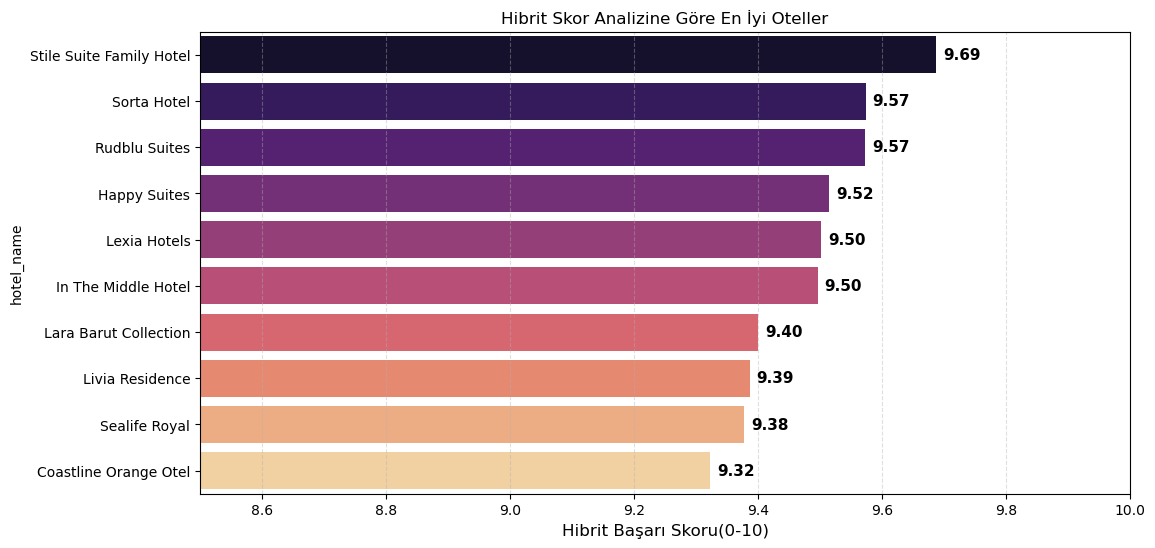

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

ax = sns.barplot(x='hybrid_score', y='hotel_name', data=top_10_hotels, palette='magma')

plt.title("Hibrit Skor Analizine Göre En İyi Oteller")
plt.xlabel("Hibrit Başarı Skoru(0-10)", fontsize=12)
plt.xlim(8.5,10)
plt.grid(axis='x', linestyle='--', alpha=0.4)

for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', xytext=(5, 0), 
                textcoords='offset points', fontsize=11, fontweight='bold')

plt.show()

Şampiyon Otel Analiz Ediliyor: Stile Suite Family Hotel




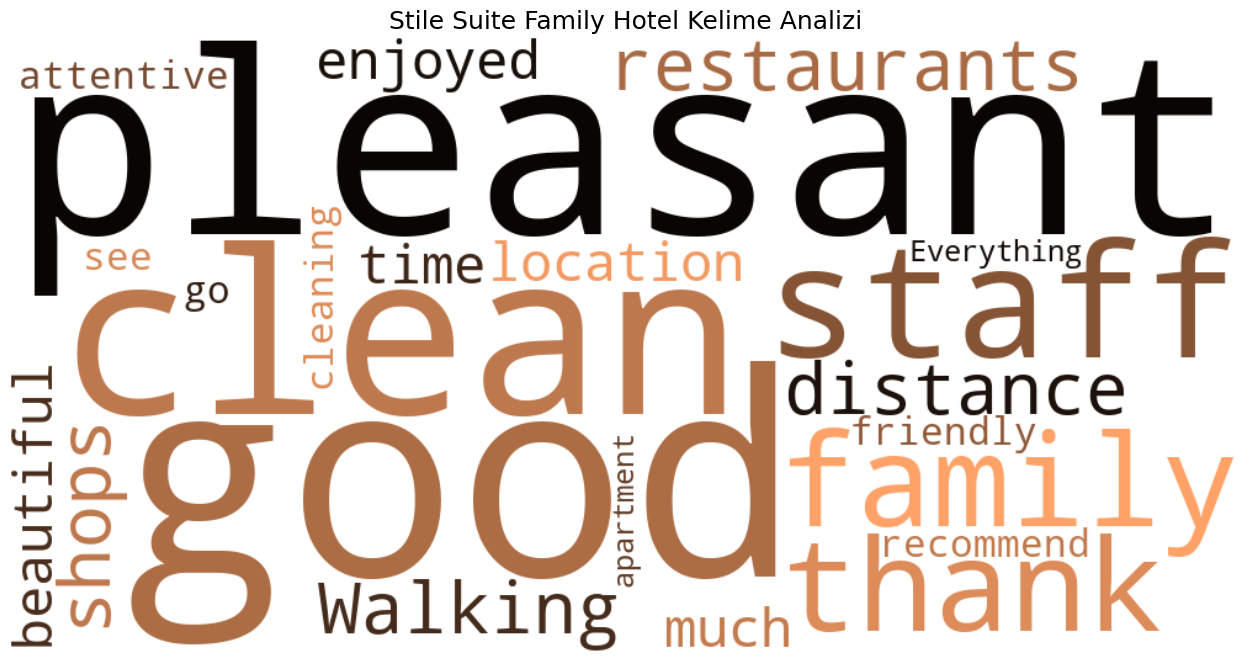

In [8]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# 1. Şampiyon Otelin İsmini Otomatik Alalım (Listedeki ilk otel)
best_hotel = top_10_hotels.iloc[0]['hotel_name']
print(f"Şampiyon Otel Analiz Ediliyor: {best_hotel}")
print("\n")

# 2. Bu otele ait TÜM yorumları tek bir devasa metin haline getirelim
# 'translated_text' sütununu kullandığından emin ol (Çevirileri de içerir)
text_data = df_final[df_final['hotel_name'] == best_hotel]['translated_text'].str.cat(sep=' ')

# 3. İstemediğimiz kelimeleri (stopwords) temizleyelim
# 'hotel', 'room', 'stay', 'day' gibi genel kelimeleri çıkaralım ki 'yemek' gibi kelimeler öne çıksın.
stopwords = set(STOPWORDS)
stopwords.update(["hotel", "room", "stay", "day", "one", "great", "excellent", "nice", "holiday", "beach"])

# 4. KELIME BULUTU OLUŞTURMA
wordcloud = WordCloud(width=1000, height=500, 
                      background_color='white', 
                      stopwords=stopwords,      # Temizleme listemiz
                      colormap='copper',        
                      max_words=100,           
                      random_state=42).generate(text_data)

# 5. GÖRSELLEŞTİRME
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Eksenleri kapat
plt.title(f"{best_hotel} Kelime Analizi", fontsize=18)
plt.show()

Bar grafiğinde sayısal olarak 1 numara çıkan otelin içyüzünü bu WordCloud ile doğruluyoruz. Gördüğünüz gibi, NLP analizimiz otelin sadece 'iyi' olduğunu değil, personel ve yemek kalitesiyle fark yarattığını kanıtlıyor. Bu, geliştirdiğim öneri sisteminin ne kadar tutarlı çalıştığının somut bir göstergesidir.

In [9]:
# Tüm hesaplamaların olduğu (hybrid_score, sentiment_10 vb.) en güncel tabloyu kaydediyoruz
df_final.to_csv('hotels_Vize_FINAL.csv', index=False, encoding='utf-8-sig')

print("Dosya adı:hotels_Vize_FINAL.csv")

Dosya adı:hotels_Vize_FINAL.csv
